In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [28]:
df = pd.read_csv("/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/crime_featured_scaled.csv")

print(df.shape)
df.head()

(494420, 12)


,Latitude,Longitude,Hour,Month,Is_Weekend,Crime_Severity_Score,Primary_Type_Encoded,Location_Encoded,Season_Encoded,Day_Encoded,Arrest,Domestic
0,0.414795,-0.574671,-1.934739,1.623297,-0.623667,-0.768661,1.388772,0.959545,1.395977,0.504356,-0.580103,-0.457865
1,0.384649,-0.674220,0.580297,-0.166550,-0.623667,-0.768661,-0.572140,0.692181,0.483884,1.496725,1.723832,-0.457865
2,0.654239,0.826550,0.432354,0.131758,-0.623667,-0.768661,1.388772,-0.356712,0.483884,-1.480381,-0.580103,-0.457865
3,-0.062458,0.608249,-0.751193,1.324989,-0.623667,-0.768661,-0.486883,0.609915,-1.340302,0.504356,-0.580103,-0.457865
4,0.609538,-1.475956,-0.307363,-0.464858,-0.623667,-0.768661,0.280431,0.692181,-0.428209,0.504356,1.723832,-0.457865


In [29]:
X = df.copy()

In [30]:
pca = PCA(n_components=0.75, random_state=42)

X_pca = pca.fit_transform(X)

print("Original Features:", X.shape[1])
print("Reduced Features:", X_pca.shape[1])
print("Total Variance Explained:", pca.explained_variance_ratio_.sum())

Original Features: 12
Reduced Features: 8
Total Variance Explained: 0.8061658882057687


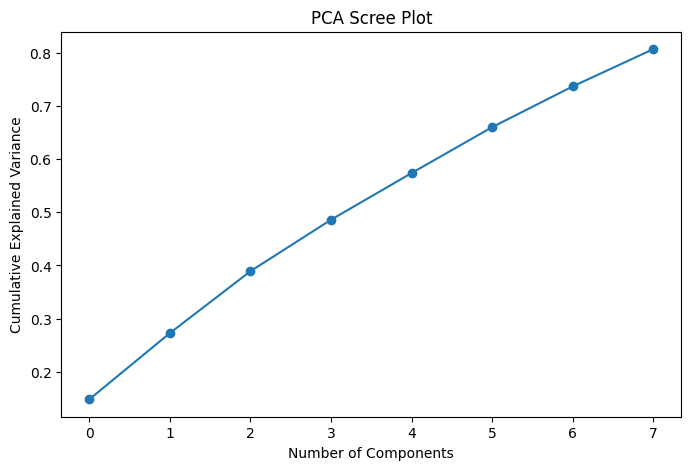

In [31]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")

plt.show()

In [32]:
pca_2 = PCA(n_components=2, random_state=42)

X_pca_2 = pca_2.fit_transform(X)

df_pca = pd.DataFrame(X_pca_2, columns=['PCA1','PCA2'])

df_pca.head()

,PCA1,PCA2
0,1.578539,0.002787
1,1.224338,-0.097362
2,1.145508,0.634893
3,0.146725,0.606550
4,1.863022,-0.658175


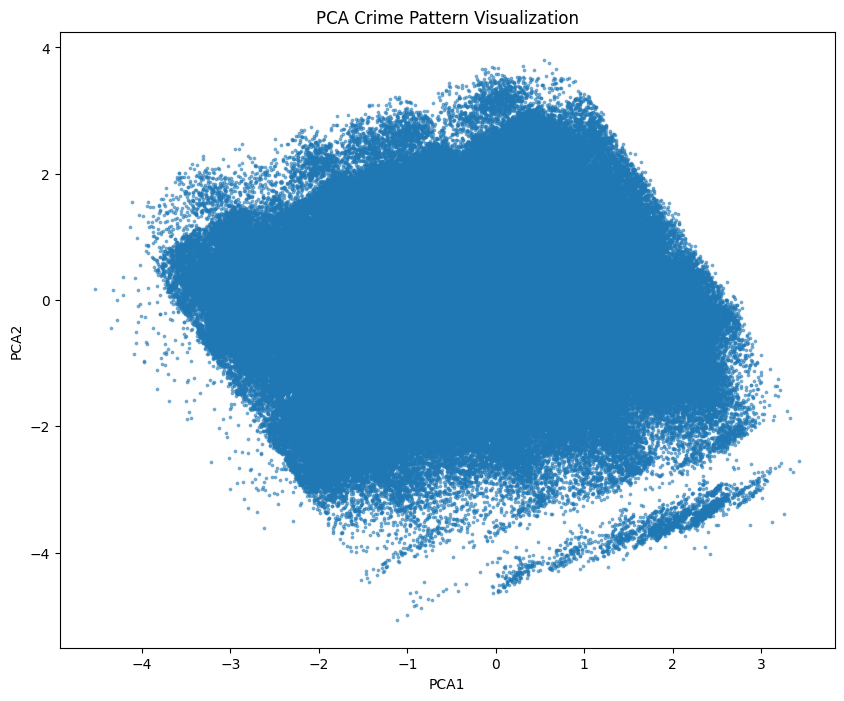

In [33]:
plt.figure(figsize=(10,8))

plt.scatter(
    df_pca['PCA1'],
    df_pca['PCA2'],
    s=3,
    alpha=0.5
)

plt.title("PCA Crime Pattern Visualization")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

<Axes: xlabel='PCA1', ylabel='PCA2'>

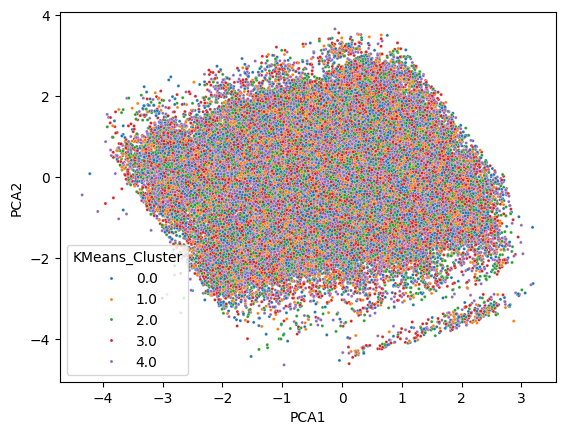

In [34]:
sns.scatterplot(
    x=df_pca['PCA1'],
    y=df_pca['PCA2'],
    hue=cluster_df['KMeans_Cluster'],
    palette='tab10',
    s=5
)

In [35]:
try:
    cluster_df = pd.read_csv("/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/crime_hotspot_clusters.csv")
    
    sample_cluster = cluster_df.sample(len(df_pca), random_state=42)
    
    plt.figure(figsize=(10,8))
    
    sns.scatterplot(
        x=df_pca['PCA1'],
        y=df_pca['PCA2'],
        hue=sample_cluster['KMeans_Cluster'],
        palette='tab10',
        s=5
    )
    
    plt.title("PCA Visualization with KMeans Clusters")
    plt.show()

except:
    print("Cluster file not found — skipping cluster color plot")

Cluster file not found — skipping cluster color plot


In [36]:
tsne_sample = X.sample(10000, random_state=42)

In [37]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    init='pca',
    max_iter=1200,
    random_state=42
)

X_tsne = tsne.fit_transform(tsne_sample)

In [38]:
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1','TSNE2'])

df_tsne.head()

,TSNE1,TSNE2
0,2.701765,-40.869843
1,-66.444519,3.632806
2,16.038399,-89.888680
3,-85.201134,-19.220835
4,-17.381193,54.292519


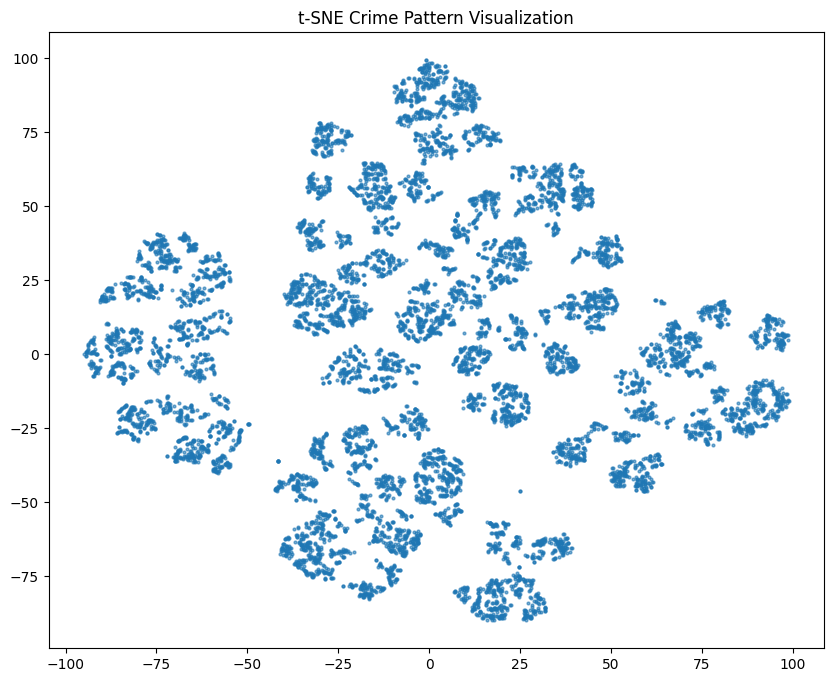

In [39]:
plt.figure(figsize=(10,8))

plt.scatter(
    df_tsne['TSNE1'],
    df_tsne['TSNE2'],
    s=4,
    alpha=0.6
)

plt.title("t-SNE Crime Pattern Visualization")
plt.show()

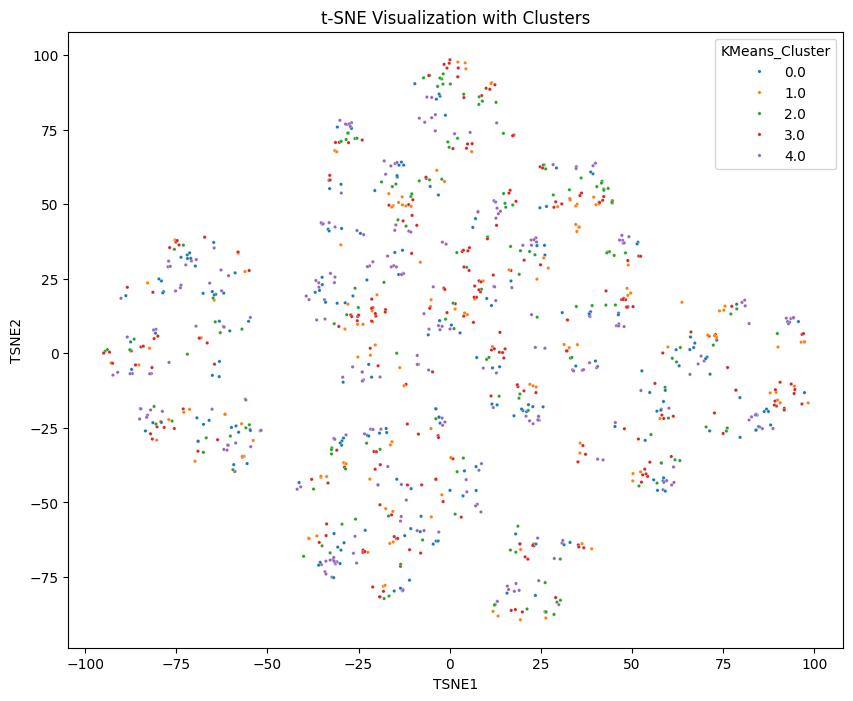

In [40]:
try:
    cluster_df = pd.read_csv("/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/crime_hotspot_clusters.csv")
    
    cluster_sample = cluster_df.sample(10000, random_state=42)
    
    plt.figure(figsize=(10,8))
    
    sns.scatterplot(
        x=df_tsne['TSNE1'],
        y=df_tsne['TSNE2'],
        hue=cluster_sample['KMeans_Cluster'],
        palette='tab10',
        s=6
    )
    
    plt.title("t-SNE Visualization with Clusters")
    plt.show()

except:
    print("Cluster file not found — skipping cluster color plot")

In [41]:
df_pca.to_csv("/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/crime_pca_2d.csv", index=False)
df_tsne.to_csv("/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/data/crime_tsne_2d.csv", index=False)

print("Reduced datasets saved ✅")

Reduced datasets saved ✅


In [42]:
import joblib
joblib.dump(pca, "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/models/pca_model.pkl")

print("PCA model saved ✅")

PCA model saved ✅


In [43]:
X = df.copy()

In [44]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [45]:
from sklearn.preprocessing import StandardScaler
import joblib
joblib.dump(scaler, "/Users/sabari/Documents/DS/GUVI/dspatrol/PatrolIQ-Smart_Safety_Analytics_Platform-main/models/scaler.pkl")

print("Scaler saved ✅")

Scaler saved ✅
